Import Library

In [1]:
from sklearn import tree
import graphviz
import matplotlib.pyplot as plt
from sklearn import datasets
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix
from sklearn.tree import DecisionTreeClassifier

**Percobaan Menggunakan Data Iris**

In [2]:
iris = datasets.load_iris()
x = pd.DataFrame(iris.data, columns=iris.feature_names)
y = pd.Categorical.from_codes(iris.target, iris.target_names)

Lihat sebagian data dari data iris

In [3]:
x.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
0,5.1,3.5,1.4,0.2
1,4.9,3.0,1.4,0.2
2,4.7,3.2,1.3,0.2
3,4.6,3.1,1.5,0.2
4,5.0,3.6,1.4,0.2


tampilkan variabel y

In [4]:
y

['setosa', 'setosa', 'setosa', 'setosa', 'setosa', ..., 'virginica', 'virginica', 'virginica', 'virginica', 'virginica']
Length: 150
Categories (3, object): ['setosa', 'versicolor', 'virginica']

variabel y diubah

In [5]:
y = pd.get_dummies(y)
y.head()

,setosa,versicolor,virginica
0,True,False,False
1,True,False,False
2,True,False,False
3,True,False,False
4,True,False,False


gunakan splitting untuk membagi data dalam data training dan data testing

In [6]:
x_train, x_test, y_train, y_test = train_test_split(x, y, random_state=1)

Bentuk model DTs dari data training menggunakan DecisionTreeClassifier

In [7]:
dt = DecisionTreeClassifier()
dt.fit(x_train, y_train)

DecisionTreeClassifier()

Melihat pohon keputusan aktual yang dihasilkan oleh model

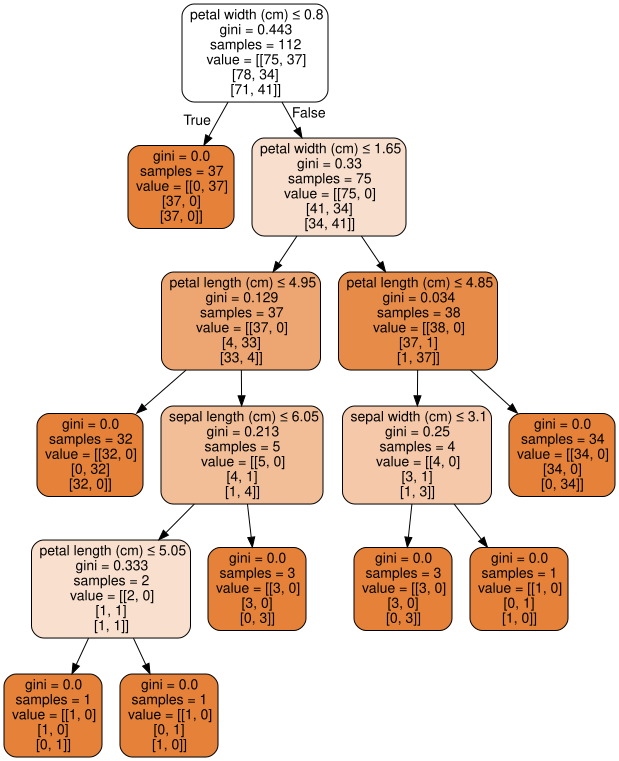

In [8]:
dot_data = tree.export_graphviz(dt, out_file=None)
graph = graphviz.Source(dot_data)
dot_data = tree.export_graphviz(dt, out_file=None,
                                feature_names=iris.feature_names,
                                class_names=iris.target_names,
                                filled=True, rounded=True,
                                special_characters=True)
graph = graphviz.Source(dot_data)
graph


 Membuat prediksi dari data dengan menggunakan hasill data training

In [9]:
y_pred = dt.predict(x_test)
y_pred

array([[ True, False, False],
       [False,  True, False],
       [False,  True, False],
       [ True, False, False],
       [False, False,  True],
       [False,  True, False],
       [False, False,  True],
       [ True, False, False],
       [ True, False, False],
       [False, False,  True],
       [False,  True, False],
       [ True, False, False],
       [False, False,  True],
       [False,  True, False],
       [False,  True, False],
       [ True, False, False],
       [False,  True, False],
       [False,  True, False],
       [ True, False, False],
       [ True, False, False],
       [False,  True, False],
       [False,  True, False],
       [False, False,  True],
       [ True, False, False],
       [False, False,  True],
       [False,  True, False],
       [ True, False, False],
       [ True, False, False],
       [False,  True, False],
       [False, False,  True],
       [False,  True, False],
       [False, False,  True],
       [False,  True, False],
       [Fa

Bentuk lain dari menentukan hasil prediksi

In [11]:
species = np.array(y_test).argmax(axis=1)
predictions = np.array(y_pred).argmax(axis=1)

Mengevaluasi hasil klasifikasi dengan confusion matrix, precision, recall dan F1

In [12]:
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

print(confusion_matrix(species, predictions))
print(classification_report(species, predictions))
print('akurasi : ', accuracy_score(species, predictions))

[[13  0  0]
 [ 0 15  1]
 [ 0  0  9]]
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        13
           1       1.00      0.94      0.97        16
           2       0.90      1.00      0.95         9

    accuracy                           0.97        38
   macro avg       0.97      0.98      0.97        38
weighted avg       0.98      0.97      0.97        38

akurasi :  0.9736842105263158


**MENGGUNAKAN DATA KAGGLE**

In [14]:
a = pd.read_csv('Food_Nutrition.csv')

Lihat sebagian data isi dari data

In [15]:
a.head()

,food_name,category,calories,protein,carbs,fat,iron,vitamin_c
0,"Apple, candied",Apples,134.0,1.34,29.61,2.15,0.12,3.6
1,"Apple, raw",Apples,61.0,0.17,14.80,0.15,0.03,4.6
2,"Apple, dried",Dried fruits,243.0,0.93,65.89,0.32,1.40,3.9
3,"Crisp, apple",Cakes and pies,215.0,2.81,30.18,9.59,1.00,0.6
4,"Apple, baked",Apples,113.0,0.32,22.70,3.08,0.19,3.9


Pisahkan fitur menjadi tipe kategori, lalu konversi menjadi one-hot encoding.

In [16]:
x = a[['calories', 'protein', 'carbs', 'fat', 'iron', 'vitamin_c']]
y = pd.Categorical(a['category'])
y = pd.get_dummies(y)

tampilkan variabel y

In [17]:
y

,American Indian/Alaska Native Foods,Apple juice,Apples,Baked Products,Bananas,"Bean, pea, legume dishes",Beverages,Blueberries and other berries,Cakes and pies,Citrus fruits,...,Sweets,Tomato-based condiments,Tomatoes,"Tortilla, corn, other chips",Vegetable dishes,Vegetable juice,Vegetables and Vegetable Products,Vegetables on a sandwich,"White potatoes, baked or boiled",Yeast breads
0,False,False,True,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
1,False,False,True,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
2,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
3,False,False,False,False,False,False,False,False,True,False,...,False,False,False,False,False,False,False,False,False,False
4,False,False,True,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
200,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,True
201,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,True
202,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
203,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False


variabel y diubah

In [18]:
y = pd.get_dummies(y)
y.head()

,American Indian/Alaska Native Foods,Apple juice,Apples,Baked Products,Bananas,"Bean, pea, legume dishes",Beverages,Blueberries and other berries,Cakes and pies,Citrus fruits,...,Sweets,Tomato-based condiments,Tomatoes,"Tortilla, corn, other chips",Vegetable dishes,Vegetable juice,Vegetables and Vegetable Products,Vegetables on a sandwich,"White potatoes, baked or boiled",Yeast breads
0,False,False,True,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
1,False,False,True,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
2,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
3,False,False,False,False,False,False,False,False,True,False,...,False,False,False,False,False,False,False,False,False,False
4,False,False,True,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False


gunakan splitting untuk membagi data dalam data training dan data testing

In [19]:
x_train, x_test, y_train, y_test = train_test_split(x, y, random_state=1)

Bentuk model DTs dari data training menggunakan DecisionTreeClassifier

In [20]:
dt = DecisionTreeClassifier()
dt.fit(x_train, y_train)

DecisionTreeClassifier()

Melihat pohon keputusan aktual yang dihasilkan oleh model

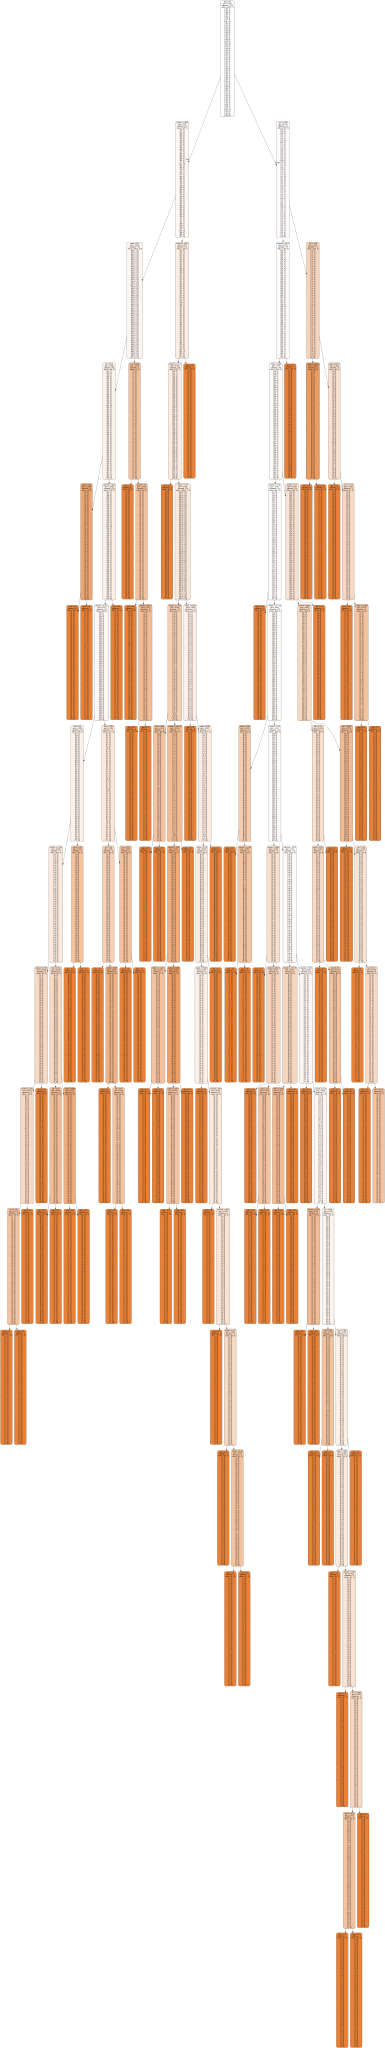

In [21]:
dot_data = tree.export_graphviz(dt, out_file=None)
graph = graphviz.Source(dot_data)
dot_data = tree.export_graphviz(dt, out_file=None,
                                feature_names=x.columns,
                                class_names=y.columns,
                                filled=True, rounded=True,
                                special_characters=True)
graph = graphviz.Source(dot_data)
graph

Membuat prediksi dari data dengan menggunakan hasill data training

In [22]:
y_pred = dt.predict(x_test)
y_pred

array([[False, False, False, ..., False, False, False],
       [False, False, False, ..., False, False, False],
       [False, False, False, ..., False, False, False],
       ...,
       [False, False, False, ..., False, False, False],
       [False, False, False, ..., False, False, False],
       [False, False, False, ..., False, False, False]])

Bentuk lain dari menentukan hasil prediksi

In [23]:
species = np.array(y_test).argmax(axis=1)
predictions = np.array(y_pred).argmax(axis=1)

Mengevaluasi hasil klasifikasi dengan confusion matrix, precision, recall dan F1

In [24]:
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

print(confusion_matrix(species, predictions))
print(classification_report(species, predictions))
print('akurasi : ', accuracy_score(species, predictions))

[[0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]
 ...
 [0 0 0 ... 2 0 0]
 [0 0 0 ... 1 0 0]
 [0 0 0 ... 0 0 3]]
              precision    recall  f1-score   support

           0       0.00      0.00      0.00         0
           1       0.00      0.00      0.00         1
           2       0.00      0.00      0.00         1
           4       0.00      0.00      0.00         1
           6       1.00      0.33      0.50         3
           8       1.00      1.00      1.00         1
           9       0.00      0.00      0.00         1
          10       0.00      0.00      0.00         1
          11       0.50      1.00      0.67         1
          12       0.00      0.00      0.00         1
          13       1.00      1.00      1.00         1
          14       0.00      0.00      0.00         1
          15       0.00      0.00      0.00         1
          17       0.00      0.00      0.00         0
          18       0.75      1.00      0.86         3
          19   

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_

**MENGGUNAKAN DATA WINE**

Import data

In [25]:
b = pd.read_csv('winequality.csv')

Lihat sebagian data isi dari data

In [26]:
b.head()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5


Pisahkan fitur menjadi tipe kategori, lalu konversi menjadi one-hot encoding.

In [27]:
x = b.drop('quality', axis=1)
y = pd.Categorical(b['quality'])
y = pd.get_dummies(y)

tampilkan variabel y

In [28]:
y

,3,4,5,6,7,8
0,False,False,True,False,False,False
1,False,False,True,False,False,False
2,False,False,True,False,False,False
3,False,False,False,True,False,False
4,False,False,True,False,False,False
...,...,...,...,...,...,...
1594,False,False,True,False,False,False
1595,False,False,False,True,False,False
1596,False,False,False,True,False,False
1597,False,False,True,False,False,False


variabel y diubah

In [29]:
y = pd.get_dummies(y)
y.head()

,3,4,5,6,7,8
0,False,False,True,False,False,False
1,False,False,True,False,False,False
2,False,False,True,False,False,False
3,False,False,False,True,False,False
4,False,False,True,False,False,False


gunakan splitting untuk membagi data dalam data training dan data testing

In [30]:
x_train, x_test, y_train, y_test = train_test_split(x, y, random_state=1)

Bentuk model DTs dari data training menggunakan DecisionTreeClassifier

In [31]:
dt = DecisionTreeClassifier()
dt.fit(x_train, y_train)

DecisionTreeClassifier()

Melihat pohon keputusan aktual yang dihasilkan oleh model

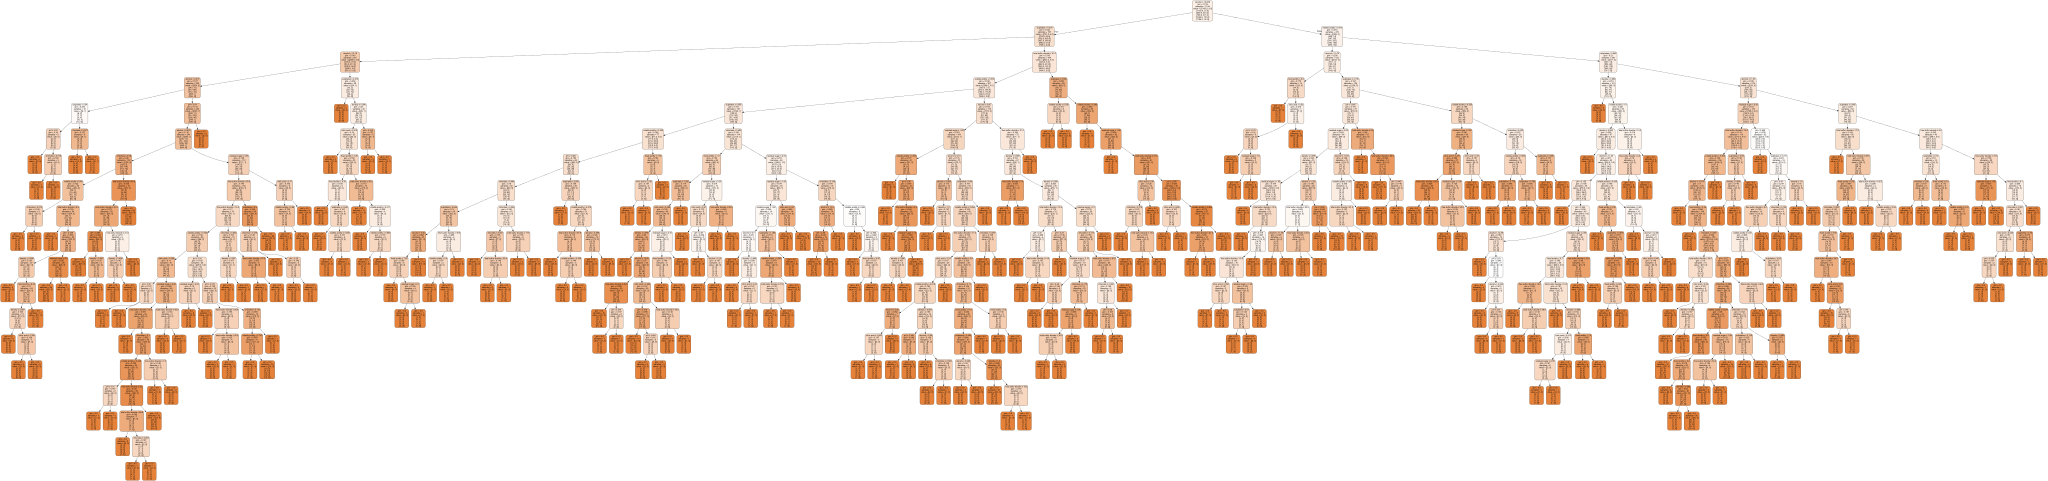

In [32]:
dot_data = tree.export_graphviz(dt, out_file=None)
graph = graphviz.Source(dot_data)
dot_data = tree.export_graphviz(dt, out_file=None,
                                feature_names=x.columns,
                                class_names=y.columns,
                                filled=True, rounded=True,
                                special_characters=True)
graph = graphviz.Source(dot_data)
graph

Membuat prediksi dari data dengan menggunakan hasill data training

In [33]:
y_pred = dt.predict(x_test)
y_pred

array([[False, False,  True, False, False, False],
       [False, False,  True, False, False, False],
       [False, False, False,  True, False, False],
       ...,
       [False, False, False, False,  True, False],
       [False, False, False,  True, False, False],
       [False, False, False,  True, False, False]])

Bentuk lain dari menentukan hasil prediksi

In [35]:
species = np.array(y_test).argmax(axis=1)
predictions = np.array(y_pred).argmax(axis=1)

Mengevaluasi hasil klasifikasi dengan confusion matrix, precision, recall dan F1

In [36]:
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

print(confusion_matrix(species, predictions))
print(classification_report(species, predictions))
print('akurasi : ', accuracy_score(species, predictions))

[[  0   0   1   0   0   0]
 [  1   1   9   4   1   0]
 [  1   3 112  52   3   0]
 [  0   4  48  96  18   1]
 [  0   0   6  10  25   1]
 [  0   0   0   1   1   1]]
              precision    recall  f1-score   support

           0       0.00      0.00      0.00         1
           1       0.12      0.06      0.08        16
           2       0.64      0.65      0.65       171
           3       0.59      0.57      0.58       167
           4       0.52      0.60      0.56        42
           5       0.33      0.33      0.33         3

    accuracy                           0.59       400
   macro avg       0.37      0.37      0.37       400
weighted avg       0.58      0.59      0.58       400

akurasi :  0.5875
